In [72]:
# STEP 1: UPLOAD DATASET
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
import pandas as pd

student_vle = pd.read_csv("/content/drive/MyDrive/PBL 2 DATASET/studentVle.csv",
                         usecols=["id_student", "sum_click"])

student_assessment = pd.read_csv("/content/drive/MyDrive/PBL 2 DATASET/studentAssessment.csv")

assessments = pd.read_csv("/content/drive/MyDrive/PBL 2 DATASET/assessments.csv")

studentInfo = pd.read_csv("/content/drive/MyDrive/PBL 2 DATASET/studentInfo.csv")

In [74]:
# STEP 2: IMPORT LIBRARIES
import pandas as pd
import numpy as np

In [75]:
# STEP 3: LOAD DATA FROM GOOGLE DRIVE
import pandas as pd

path = "/content/drive/MyDrive/PBL 2 DATASET/"

student_vle = pd.read_csv(
    path + "studentVle.csv",
    usecols=["id_student", "sum_click"],
    on_bad_lines='skip',
    low_memory=False
)

student_assessment = pd.read_csv(
    path + "studentAssessment.csv",
    on_bad_lines='skip',
    low_memory=False
)

assessments = pd.read_csv(
    path + "assessments.csv",
    on_bad_lines='skip',
    low_memory=False
)

student_info = pd.read_csv(
    path + "studentInfo.csv",
    on_bad_lines='skip',
    low_memory=False
)

In [76]:
# STEP 4: UNDERSTAND DATA (Checking column names)
print("studentVle:", student_vle.columns)
print("studentAssessment:", student_assessment.columns)
print("assessments:", assessments.columns)
print("student_info:",student_info.columns)
# Remove NaN
student_vle = student_vle.fillna(0)
student_assessment = student_assessment.fillna(0)
assessments = assessments.fillna(0)
student_info = student_info.fillna(0)

studentVle: Index(['id_student', 'sum_click'], dtype='object')
studentAssessment: Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], dtype='object')
assessments: Index(['code_module', 'code_presentation', 'id_assessment', 'assessment_type',
       'date', 'weight'],
      dtype='object')
student_info: Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result'],
      dtype='object')


In [77]:
# STEP 4 part 2 : FEATURE CREATION

# Engagement (clicks)
vle_data = student_vle.groupby("id_student")["sum_click"].sum().reset_index()

# Submission delay
merged = pd.merge(student_assessment, assessments, on="id_assessment")

merged["submission_delay"] = merged["date_submitted"] - merged["date"]

delay_data = merged.groupby("id_student")["submission_delay"].mean().reset_index()

In [78]:
# STEP 5: MERGE FINAL DATA
final_data = pd.merge(vle_data, delay_data, on="id_student")

In [79]:
# STEP 5.5: ADD STUDENT INFO
student_info = student_info[
    ["id_student", "num_of_prev_attempts", "studied_credits"]
]

final_data = pd.merge(final_data, student_info, on="id_student", how="left")

final_data = final_data.fillna(0)

In [80]:
# STEP 6: EXTRA FEATURES
final_data["delay_abs"] = final_data["submission_delay"].abs()

final_data["engagement_level"] = pd.cut(
    final_data["sum_click"],
    bins=[0, 1000, 3000, 10000],
    labels=[0,1,2]
)

final_data["engagement_level"] = final_data["engagement_level"].astype(float)

In [81]:
# STEP 7: CREATE TARGET
import numpy as np

final_data["score"] = (
    final_data["sum_click"].rank(pct=True) * -1 +
    final_data["submission_delay"].rank(pct=True) +
    np.random.rand(len(final_data)) * 0.3
)

final_data["burnout_risk"] = pd.qcut(
    final_data["score"],
    q=3,
    labels=[0,1,2]
).astype(int)

print(final_data["burnout_risk"].value_counts())

burnout_risk
0    8907
1    8907
2    8907
Name: count, dtype: int64


In [82]:
# STEP 8.5: FEATURE ENGINEERING
final_data["engagement_per_day"] = final_data["sum_click"] / (final_data["num_of_prev_attempts"] + 1)

final_data["delay_ratio"] = final_data["submission_delay"] / (final_data["delay_abs"] + 1)

final_data["click_intensity"] = final_data["sum_click"] / (final_data["studied_credits"] + 1)

final_data["activity_score"] = final_data["sum_click"] * final_data["engagement_level"]

In [83]:
# STEP 8: PREPARE DATA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = final_data[
    [
        "sum_click",
        "submission_delay",
        "delay_abs",
        "engagement_level",
        "engagement_per_day",
        "delay_ratio",
        "click_intensity",
        "activity_score",
        "num_of_prev_attempts",
        "studied_credits"
    ]
]

y = final_data["burnout_risk"]

X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:\n", y_train.value_counts())

Train:
 burnout_risk
0    7126
2    7125
1    7125
Name: count, dtype: int64


In [84]:
# STEP 9: TRAIN MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

!pip install xgboost
from xgboost import XGBClassifier

# Models
lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# XGBOOST (MAIN MODEL)
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train all
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:46:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [91]:
import joblib

joblib.dump(rf, "model.pkl")

['model.pkl']

In [92]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
# STEP 10: EVALUATION

from sklearn.metrics import accuracy_score, classification_report

print("Logistic:", accuracy_score(y_test, lr.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
print("XGBoost:", accuracy_score(y_test, xgb.predict(X_test)))

print("\n--- Classification Report (XGBoost) ---")
print(classification_report(y_test, xgb.predict(X_test)))

Logistic: 0.8710944808231993
Random Forest: 0.8873713751169318
Decision Tree: 0.8579981290926099
XGBoost: 0.8813844714686623

--- Classification Report (XGBoost) ---
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1781
           1       0.82      0.83      0.82      1782
           2       0.91      0.90      0.90      1782

    accuracy                           0.88      5345
   macro avg       0.88      0.88      0.88      5345
weighted avg       0.88      0.88      0.88      5345



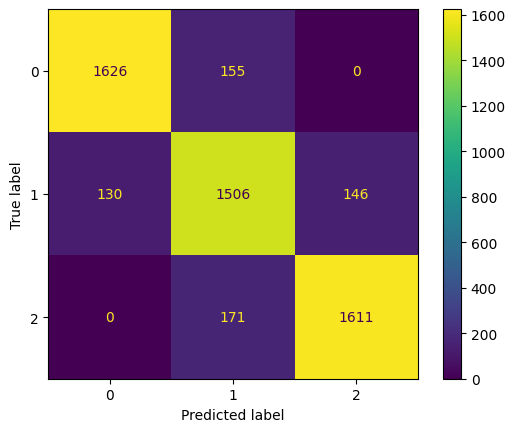

In [86]:
# STEP 11: CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

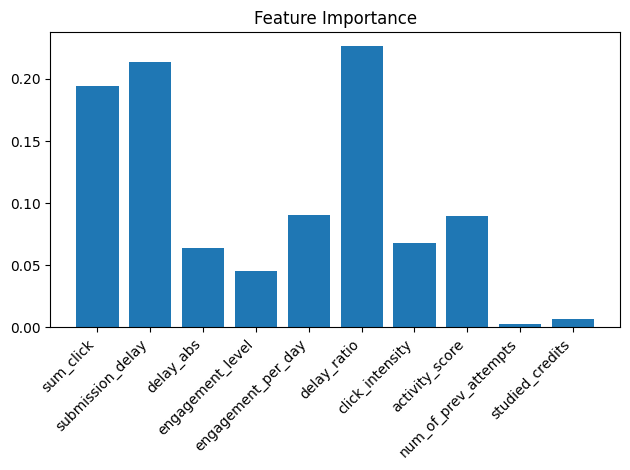

In [88]:
# STEP 12 : FEATURE IMPORTANCE
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = [
    "sum_click",
    "submission_delay",
    "delay_abs",
    "engagement_level",
    "engagement_per_day",
    "delay_ratio",
    "click_intensity",
    "activity_score",
    "num_of_prev_attempts",
    "studied_credits"
]

plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

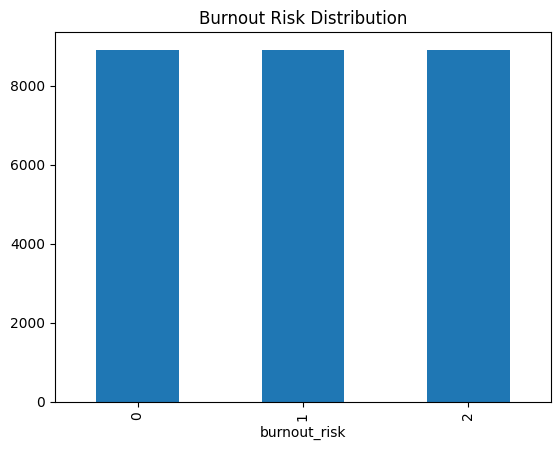

In [89]:
# STEP 13: BURNOUT DISTRIBUTION GRAPH
final_data["burnout_risk"].value_counts().plot(kind='bar')
plt.title("Burnout Risk Distribution")
plt.show()

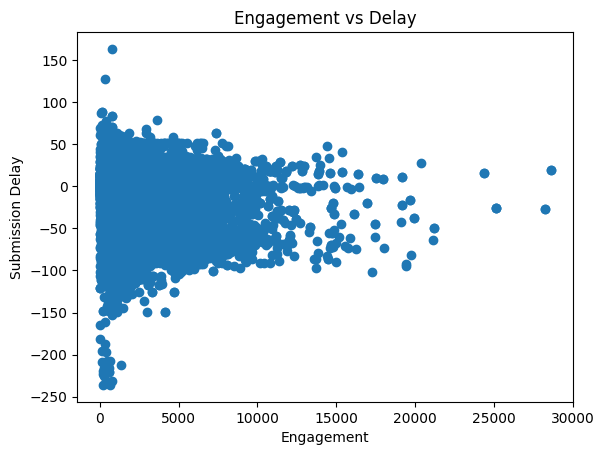

In [90]:
# STEP 14: SCATTER PLOT
plt.scatter(final_data["sum_click"], final_data["submission_delay"])
plt.xlabel("Engagement")
plt.ylabel("Submission Delay")
plt.title("Engagement vs Delay")
plt.show()